# Clustering

## kMeans

kMeans is an unsupervised learning algorithm that partitions n observations into k clusters. Each observation belongs to the cluster with the nearest mean (cluster center or centroid).


### 1. kMeans Implementation
* Implementing the kMeans clustering algorithm using `numpy` only.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class KMeans:
    def __init__(self, k=3, max_iters=100, tol=1e-4, random_state=None):
        """
        Initialize KMeans clusterer.

        Parameters:
        -----------
        k : int
            Number of clusters
        max_iters : int
            Maximum number of iterations
        tol : float
            Tolerance for convergence (change in centroids)
        random_state : int or None
            Random seed for reproducibility
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.labels_ = None


        # Extra attributes
        self.cluster_centers_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.inertia_history_ = []
        self.shift_history_ = []

    def initialize_centroids(self, X):
        """
        Initialize cluster centers using random selection from data points.
        """
        n = X.shape[0]
        idx = np.random.choice(n, self.k, replace=False)
        return X[idx].copy()

    def initialize_centroids_plusplus(self, X):  # for the following Subtask
        """
        KMeans++ initialization.
        """
        n, d = X.shape
        centers = np.empty((self.k, d), dtype=X.dtype)
        # First center uniformly at random
        i0 = np.random.randint(n)
        centers[0] = X[i0]
        # Distances to nearest chosen center (squared)
        closest_dist_sq = np.sum((X - centers[0])**2, axis=1)
        for i in range(1, self.k):
            probs = closest_dist_sq / np.sum(closest_dist_sq)
            idx = np.random.choice(n, p=probs)
            centers[i] = X[idx]
            dist_sq = np.sum((X - centers[i])**2, axis=1)
            closest_dist_sq = np.minimum(closest_dist_sq, dist_sq)
        return centers

    def _assign_labels(self, X, centers):
        # Squared Euclidean distances to centers
        dists_sq = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)
        labels = np.argmin(dists_sq, axis=1)
        return labels, dists_sq

    def _compute_centers(self, X, labels):
        d = X.shape[1]
        centers = np.zeros((self.k, d), dtype=X.dtype)
        for j in range(self.k):
            mask = (labels == j)
            if np.any(mask):
                centers[j] = X[mask].mean(axis=0)
            else:
                # Reinitialize empty cluster to a random data point
                centers[j] = X[np.random.randint(X.shape[0])]
        return centers

    def fit(self, X):
        """
        Fit the KMeans model to data X.
        """
        X = np.asarray(X)
        if self.random_state is not None:
            np.random.seed(self.random_state)

        centers = self.initialize_centroids(X)  # default: random init
        self.inertia_history_.clear()
        self.shift_history_.clear()

        for it in range(self.max_iters):
            labels, dists_sq = self._assign_labels(X, centers)
            new_centers = self._compute_centers(X, labels)
            # Convergence criterion: max centroid shift
            shift = np.linalg.norm(new_centers - centers, axis=1).max()
            inertia = dists_sq[np.arange(X.shape[0]), labels].sum()

            self.shift_history_.append(float(shift))
            self.inertia_history_.append(float(inertia))

            centers = new_centers
            if shift <= self.tol:
                break

        # Final assignment and stats
        labels, dists_sq = self._assign_labels(X, centers)
        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = dists_sq[np.arange(X.shape[0]), labels].sum()
        self.n_iter_ = len(self.shift_history_)
        return self

    def predict(self, X):
        """
        Predict cluster labels for new data.
        """
        X = np.asarray(X)
        dists_sq = ((X[:, None, :] - self.cluster_centers_[None, :, :])**2).sum(axis=2)
        return np.argmin(dists_sq, axis=1)

    def fit_predict(self, X):
        """
        Perform KMeans clustering and return cluster labels.
        """
        self.fit(X)
        return self.labels_


Converged in 20 iterations, inertia=570.75


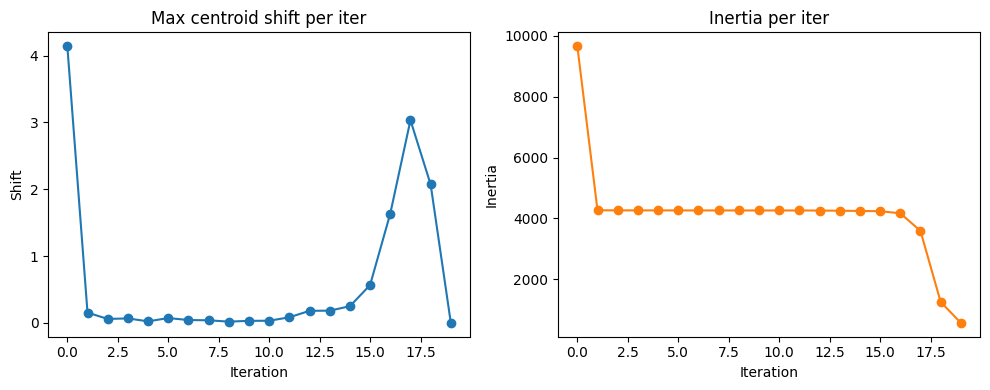

In [ ]:
# Synthetic 2D data with 4 clusters
np.random.seed(42)
centers_true = np.array([[0, 0], [5, 5], [-5, 5], [5, -5]])
X_parts = []
for c in centers_true:
    X_parts.append(np.random.randn(150, 2) * 0.7 + c)
X = np.vstack(X_parts)

# Run k-means with random initialization
km = KMeans(k=4, max_iters=100, tol=1e-4, random_state=7)
labels = km.fit_predict(X)
print(f"Converged in {km.n_iter_} iterations, inertia={km.inertia_:.2f}")

# Plot centroid shift and inertia per iteration
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(km.shift_history_, marker='o')
ax[0].set_title("Max centroid shift per iter")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Shift")

ax[1].plot(km.inertia_history_, marker='o', color='tab:orange')
ax[1].set_title("Inertia per iter")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Inertia")
plt.tight_layout()
plt.show()


### 2. kMeans++ initialization

* Implementing the kMeans++ initialization method in the KMeans class.
* Comparing the convergence speed of kMeans with random initialization and kMeans++ initialization on your synthetic dataset from previous part.

Random init: iters=20, final inertia=570.75
KMeans++   : iters=7, final inertia=570.75


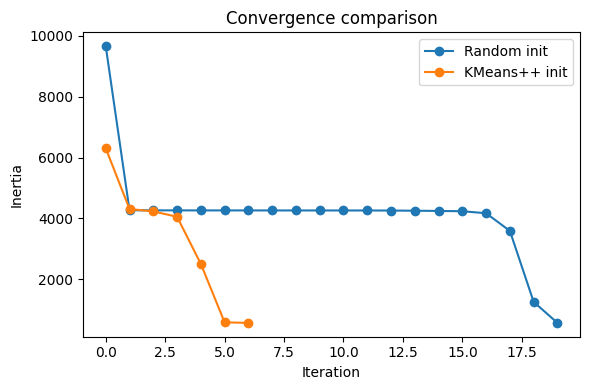

In [ ]:
# Random init vs. KMeans++ init comparison
km_rand = KMeans(k=4, max_iters=100, tol=1e-4, random_state=7)
km_rand.fit(X)

km_pp = KMeans(k=4, max_iters=100, tol=1e-4, random_state=7)
# Switch the initializer to KMeans++
km_pp.initialize_centroids = km_pp.initialize_centroids_plusplus
km_pp.fit(X)

print(f"Random init: iters={km_rand.n_iter_}, final inertia={km_rand.inertia_:.2f}")
print(f"KMeans++   : iters={km_pp.n_iter_}, final inertia={km_pp.inertia_:.2f}")

# Plot inertia histories side-by-side
plt.figure(figsize=(6,4))
plt.plot(km_rand.inertia_history_, '-o', label='Random init')
plt.plot(km_pp.inertia_history_, '-o', label='KMeans++ init')
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("Convergence comparison")
plt.legend()
plt.tight_layout()
plt.show()



### 3. Visualization of Cluster Quality


* Visualizing the clustering results of your kMeans implementation on a synthetic 2D dataset.


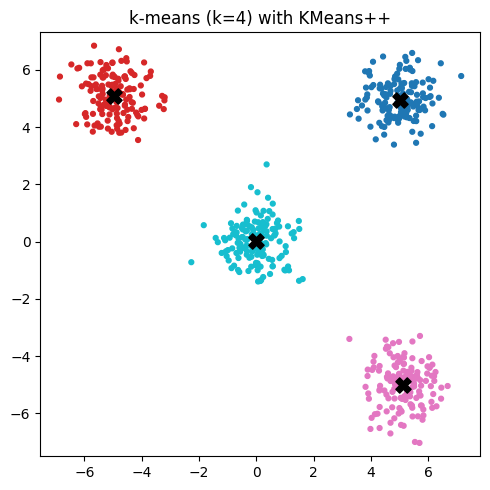

In [ ]:
def plot_clusters(X, labels, centers=None, title="Clusters"):
    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], c=labels, s=12, cmap='tab10')
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], c='black', s=120, marker='X')
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

plot_clusters(X, km_pp.labels_, km_pp.cluster_centers_, title="k-means (k=4) with KMeans++")


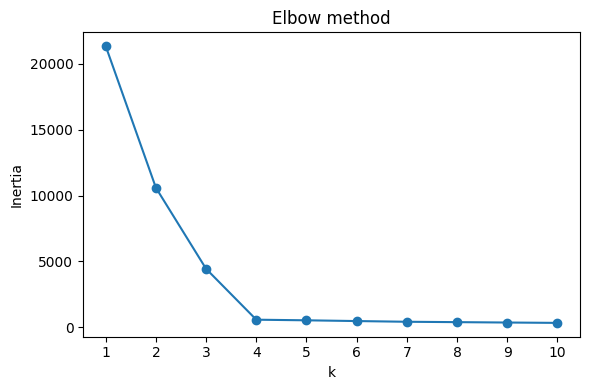

Visual elbow should be near k=4 on this dataset.


In [ ]:
# Elbow method (k = 1..10)
ks = range(1, 11)
inertias = []
for k in ks:
    model = KMeans(k=k, max_iters=100, tol=1e-4, random_state=0)
    _ = model.fit_predict(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(ks, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.xticks(list(ks))
plt.tight_layout()
plt.show()

print("Visual elbow should be near k=4 on this dataset.")


In [ ]:
# Numpy-only silhouette score (ignoring noise labels if present)
def silhouette_score_numpy(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Exclude noise label (-1) if present
    mask_valid = labels != -1
    Xv = X[mask_valid]
    lv = labels[mask_valid]

    n = Xv.shape[0]
    if n <= 1:
        return 0.0

    # Pairwise Euclidean distances
    diff = Xv[:, None, :] - Xv[None, :, :]
    D = np.sqrt((diff**2).sum(axis=2))

    unique = np.unique(lv)
    # Precompute masks per cluster
    cluster_masks = {c: (lv == c) for c in unique}

    a = np.zeros(n, dtype=float)
    b = np.zeros(n, dtype=float)

    for i in range(n):
        ci = lv[i]
        same = cluster_masks[ci]
        # Intra-cluster distances (exclude self)
        if same.sum() > 1:
            a[i] = D[i, same].sum() / (same.sum() - 1)
        else:
            a[i] = 0.0  # singleton cluster

        # Mean distance to other clusters, take min
        means_other = []
        for c in unique:
            if c == ci:
                continue
            mask_c = cluster_masks[c]
            means_other.append(D[i, mask_c].mean() if mask_c.any() else np.inf)
        b[i] = np.min(means_other) if len(means_other) > 0 else 0.0

    s = (b - a) / np.maximum(a, b + 1e-12)
    return float(np.nanmean(s))

# Silhouette for optimal k (assume 4) and k-1 (3)
km_k4 = KMeans(k=4, max_iters=100, tol=1e-4, random_state=1)
lab_k4 = km_k4.fit_predict(X)
s_k4 = silhouette_score_numpy(X, lab_k4)

km_k3 = KMeans(k=3, max_iters=100, tol=1e-4, random_state=1)
lab_k3 = km_k3.fit_predict(X)
s_k3 = silhouette_score_numpy(X, lab_k3)

print(f"Silhouette k=4: {s_k4:.4f}")
print(f"Silhouette k=3: {s_k3:.4f}")


Silhouette k=4: 0.8224
Silhouette k=3: 0.6608


## DBSCAN

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, marking outliers points that lie alone in low-density regions.

* Implementing the DBSCAN algorithm using `numpy` only. Use the `DBSCAN`.
* Testing DBSCAN implementation on a synthetic 2D dataset with noise. Visualizing the clustering results using matplotlib.
* Comparing the performance of your DBSCAN implementation with kMeans implementation on the same synthetic 2D dataset using silhouette score as a metric.


In [ ]:
from collections import deque  # Useful for efficient BFS implementation (FIFO) for iterating through neighboring points

class DBSCAN:
    def __init__(self, eps=0.5, min_samples=5, metric='euclidean'):
        """
        Parameters:
        -----------
        eps : float
            Maximum distance between two samples for them to be considered neighbors
        min_samples : int
            Number of samples in a neighborhood for a point to be considered a core point
            (including the point itself)
        metric : str
            Distance metric to use ('euclidean' or 'manhattan')
        """
        self.eps = eps
        self.min_samples = min_samples
        self.metric = metric
        self.labels_ = None
        self.core_sample_indices_ = None
        self.components_ = None
        self.n_clusters_ = None
        self.n_noise_ = None

        # internal
        self._core_mask = None
        self._core_labels = None  # labels for core samples (aligned with core_sample_indices_)

    def _pairwise_dists_one(self, X, i):
        if self.metric == 'euclidean':
            diff = X - X[i]
            return np.sqrt((diff**2).sum(axis=1))
        elif self.metric == 'manhattan':
            return np.abs(X - X[i]).sum(axis=1)
        else:
            raise ValueError("Unsupported metric")

    def _region_query(self, X, i):
        d = self._pairwise_dists_one(X, i)
        return np.where(d <= self.eps)[0]

    def fit(self, X):
        """
        Perform DBSCAN clustering.
        """
        X = np.asarray(X)
        n = X.shape[0]
        labels = -np.ones(n, dtype=int)  # -1 means noise / unassigned
        visited = np.zeros(n, dtype=bool)

        cluster_id = 0
        core_mask = np.zeros(n, dtype=bool)

        for i in range(n):
            if visited[i]:
                continue
            visited[i] = True

            neighbors = self._region_query(X, i)
            if neighbors.size < self.min_samples:
                # noise for now
                labels[i] = -1
            else:
                # core point, expand cluster
                core_mask[i] = True
                labels[i] = cluster_id
                queue = deque(neighbors.tolist())

                while queue:
                    j = queue.popleft()
                    if not visited[j]:
                        visited[j] = True
                        neighbors_j = self._region_query(X, j)
                        if neighbors_j.size >= self.min_samples:
                            core_mask[j] = True
                            # add new neighbors to queue
                            for nb in neighbors_j:
                                if not (labels[nb] != -1 or nb in queue):
                                    queue.append(nb)
                    # assign to cluster if not yet assigned
                    if labels[j] == -1:
                        labels[j] = cluster_id

                cluster_id += 1

        # Update attributes
        self.labels_ = labels
        self.n_clusters_ = int(np.max(labels) + 1) if np.any(labels != -1) else 0
        self.n_noise_ = int(np.sum(labels == -1))
        self.core_sample_indices_ = np.where(core_mask)[0]
        self.components_ = X[self.core_sample_indices_]

        # Map core sample index -> cluster label for prediction
        core_labels = labels[self.core_sample_indices_]
        self._core_mask = core_mask
        self._core_labels = core_labels
        return self

    def predict(self, X_new):
        """
        Predict the closest cluster for new points.
        Note: New points can only be assigned to existing clusters or marked as noise.
        """
        if self.components_ is None or self._core_labels is None:
            raise RuntimeError("DBSCAN must be fit before predict.")

        X_new = np.asarray(X_new)
        if X_new.ndim == 1:
            X_new = X_new[None, :]

        if self.components_.shape[0] == 0:
            return -np.ones(X_new.shape[0], dtype=int)

        # Compute distances to core samples
        if self.metric == 'euclidean':
            diff = X_new[:, None, :] - self.components_[None, :, :]
            dists = np.sqrt((diff**2).sum(axis=2))
        else:
            dists = np.abs(X_new[:, None, :] - self.components_[None, :, :]).sum(axis=2)

        nearest_idx = np.argmin(dists, axis=1)
        nearest_dist = dists[np.arange(X_new.shape[0]), nearest_idx]
        labels_pred = np.where(nearest_dist <= self.eps, self._core_labels[nearest_idx], -1)
        return labels_pred

    def fit_predict(self, X):
        """
        Perform DBSCAN clustering and return cluster labels.
        """
        self.fit(X)
        return self.labels_


DBSCAN: clusters=15, noise=34


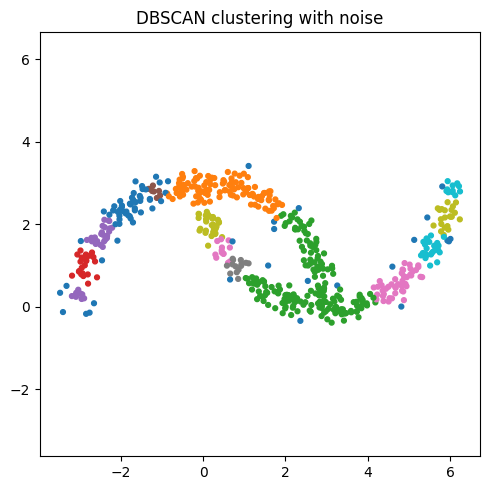

Silhouette DBSCAN: 0.3023
Silhouette k-means (k=2): 0.5243


In [ ]:
# Noisy two-moons-like dataset (procedurally with numpy)
np.random.seed(123)
n = 600
theta = np.random.rand(n//2) * np.pi
moon1 = np.c_[np.cos(theta), np.sin(theta)] + 0.06*np.random.randn(n//2,2)
moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta)] + 0.06*np.random.randn(n//2,2)
X_noise = np.vstack([moon1, moon2]) * 3.0

# Run DBSCAN
db = DBSCAN(eps=0.25, min_samples=10, metric='euclidean').fit(X_noise)
labels_db = db.labels_
print(f"DBSCAN: clusters={db.n_clusters_}, noise={db.n_noise_}")

# Visualize DBSCAN result
plt.figure(figsize=(5,5))
plt.scatter(X_noise[:,0], X_noise[:,1], c=labels_db, s=12, cmap='tab10')
plt.title("DBSCAN clustering with noise")
plt.axis('equal')
plt.tight_layout()
plt.show()

# Compare silhouette vs k-means on same data
km2 = KMeans(k=2, max_iters=100, tol=1e-4, random_state=123)
lab_km2 = km2.fit_predict(X_noise)

s_db = silhouette_score_numpy(X_noise, labels_db)
s_km = silhouette_score_numpy(X_noise, lab_km2)
print(f"Silhouette DBSCAN: {s_db:.4f}")
print(f"Silhouette k-means (k=2): {s_km:.4f}")
